# Tranfer Learning VGG16 Chapter 10 Workshop 1

## Load module

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import load_model


## Declare variable

In [2]:
target_img_shape = (224, 224)

train_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\train_set'
test_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\test_set'
val_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\val_set'

# Define process input for VGG
# train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Define process input for VGG with Data Augmentation
train_datagen = ImageDataGenerator(
                            preprocessing_function=preprocess_input,
                            rotation_range=20,
                            width_shift_range=0.15,
                            height_shift_range=0.15,
                            shear_range=0.2,
                            zoom_range=0.2,
                            horizontal_flip=True,
                            fill_mode='nearest'
)

train_set = train_datagen.flow_from_directory(train_dir,
                                                  target_size=target_img_shape,
                                                  batch_size=32,
                                                  class_mode='binary')


val_datagen = ImageDataGenerator(
                            preprocessing_function=preprocess_input,
                            rotation_range=20,
                            width_shift_range=0.15,
                            height_shift_range=0.15,
                            shear_range=0.2,
                            zoom_range=0.2,
                            horizontal_flip=True,
                            fill_mode='nearest'
)

val_set = val_datagen.flow_from_directory(val_dir,
                                                  target_size=target_img_shape,
                                                  batch_size=32,
                                                  class_mode='binary')

Found 15997 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


## Check data_set

In [3]:
batch = next(train_set) # train_set.next()
# train_set.next()
print(batch[0].shape)
print(batch[1].shape)

(32, 224, 224, 3)
(32,)


[0 0 0 ... 1 1 1]
(32, 224, 224, 3)
(32,)
['dog', 'cat', 'cat', 'dog', 'dog', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'cat', 'dog', 'cat', 'dog', 'cat', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'dog', 'cat', 'cat', 'dog', 'dog', 'cat', 'dog', 'cat', 'cat', 'cat']
-123.68 151.061


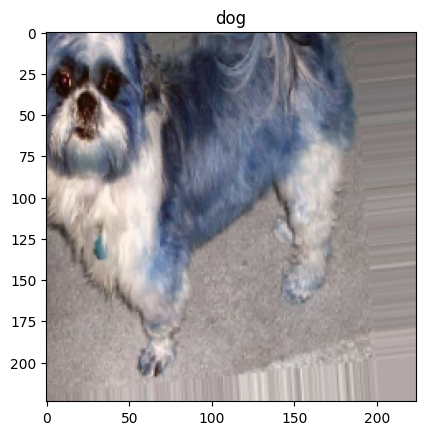

In [4]:
print(train_set.labels)
labels = train_set.class_indices
labels = {v: k for k, v in labels.items()} # dict((v, k) for k, v in labels_batch[0].items())

for image_batch, labels_batch in train_set:
    print(image_batch.shape)
    print(labels_batch.shape)
    
    labels_batch =  list(map(lambda x: labels[x], labels_batch))
    print(labels_batch)

    img = image_batch[0] - np.min(image_batch[0])
    img = img / np.max(img)

    print(np.min(image_batch[0]), np.max(image_batch[0]))
    plt.imshow(img)
    plt.title(labels_batch[0])
    
    break

In [5]:
ids, counts = np.unique(train_set.classes, return_counts=True)
print(ids)
print(counts)

[0 1]
[7997 8000]


In [6]:
for i in ids:
    print(labels[i], counts[i])

cat 7997
dog 8000


## Create model

### Create base model

In [7]:
in_shape = (target_img_shape[0], target_img_shape[1], 3)
in_shape

(224, 224, 3)

#### base model from VGG16 instance

In [8]:
base_model = VGG16(weights='imagenet', 
                   include_top=False, 
                   input_shape=in_shape)
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

#### base model from saved model

In [9]:
# from tensorflow.keras.models import Model, load_model

# # Load the full VGG16 model (with top layers)
# raw_model = load_model('./model/vgg16_model.h5')

# # Inspect the layers (optional)
# for i, layer in enumerate(raw_model.layers):
#     print(i, layer.name)

# # Get the last layer of the convolutional base
# # For VGG16, this is usually 'block5_pool'
# conv_base_output = raw_model.get_layer('block5_pool').output

# # Create a new model with the same input but truncated after the conv base
# base_model_from_raw = Model(inputs=raw_model.input, outputs=conv_base_output)

# # Now base_model_from_raw behaves like base_model1
# base_model_from_raw.summary()

### Combine base model with new top

In [10]:
model = Sequential()

model.add(base_model) # base_model_from_raw 
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 128)               3211392   
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 17,926,209
Trainable params: 17,926,209
Non-trainable params: 0
_________________________________________________________________


In [11]:
for layer in model.layers:
    print(layer.name, layer.trainable)

vgg16 True
flatten True
dense True
dense_1 True


### Freeze Feature Extraction layer

In [12]:
# base_model_from_raw.trainable = False
base_model.trainable = False

In [13]:
print("Trainable..\n---")
for var in model.trainable_variables:
    print(var.name)

model.summary()

Trainable..
---
dense/kernel:0
dense/bias:0
dense_1/kernel:0
dense_1/bias:0
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 128)               3211392   
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 17,926,209
Trainable params: 3,211,521
Non-trainable params: 14,714,688
_________________________________________________________________


## Compile model

In [14]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Train model

In [ ]:
import time

es = EarlyStopping(monitor='val_loss',
                   patience=5,
                   verbose=1,
                   restore_best_weights=True)
mc = ModelCheckpoint('model/test_model_with_gpu.h5',
                       monitor='val_accuracy',
                       save_best_only=True,
                       verbose=1)

start = time.time()
# with tf.device('/GPU:0'):
#     history = model.fit(train_set,
#                         steps_per_epoch=len(train_set),
#                         epochs=20,
#                         validation_data=val_set,
#                         callbacks=[es, mc],
#                         verbose=1
#                         )

history = model.fit(train_set,
                        steps_per_epoch=len(train_set),
                        epochs=20,
                        validation_data=val_set,
                        callbacks=[es, mc],
                        verbose=1
                        )

end = time.time()

print("Training time: ", round(end - start)/60, 2, "minites")


# Find-tuning Chapter 10 Workshop 2

In [19]:
model = load_model('model/best_tranfer_vgg16_model.h5')
model.summary()

for var in model.trainable_variables:
    print(var.name, var.trainable)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_25 (Functional)      │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,211 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2 (12.00 B)

kernel True
bias True
kernel True
bias True


In [26]:
score = model.evaluate(val_set,verbose=1)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

63/63 [==============================] - 12s 189ms/step - loss: 0.0529 - accuracy: 0.9810
Test loss: 0.05293279513716698
Test accuracy: 0.9810000061988831


# Find-tuning Chapter 10 Workshop 2

## Load model

In [42]:
# model_path = "D:\Project\Learning\TensorFlow_Files\Project\model\best_tranfer_vgg16_model.h5"
ld_model = load_model('./model/test_model_with_gpu.h5')

## Check model

### summary load model

In [43]:
ld_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 128)               3211392   
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 17,926,209
Trainable params: 3,211,521
Non-trainable params: 14,714,688
_________________________________________________________________


### Check load model trainable

In [44]:
print("Trainable..\n---")
for var in ld_model.trainable_variables:
    print(var.name)

Trainable..
---
dense/kernel:0
dense/bias:0
dense_1/kernel:0
dense_1/bias:0


In [45]:
for layer in ld_model.layers:
    print(layer.name, layer.trainable)

vgg16 True
flatten True
dense True
dense_1 True


## Get base model from load model

In [46]:
base_layer_name = ld_model.layers[0].name
new_base_model = ld_model.get_layer(base_layer_name)
new_base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

## Unfreeze some layer in base_layer

### check layer in base layer

In [47]:

for layer in new_base_model.layers:
    print(layer.name, layer.trainable)
print("------------------------------")


input_1 True
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False
------------------------------


### unfreeze some layer

In [48]:
for layer in new_base_model.layers[-8:]:
    print(layer.name)
    layer.trainable = True
print("------------------------------")

block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool
------------------------------


In [52]:
fine_tune_vgg16_model = Sequential()
fine_tune_vgg16_model.add(new_base_model)
fine_tune_vgg16_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
Total params: 14,714,688
Trainable params: 12,979,200
Non-trainable params: 1,735,488
_________________________________________________________________


## Add new layer for specific purpose

In [55]:
fine_tune_vgg16_model.add(Flatten())
fine_tune_vgg16_model.add(Dense(128, activation='relu'))
fine_tune_vgg16_model.add(Dense(1, activation='sigmoid'))

fine_tune_vgg16_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 dense_2 (Dense)             (None, 7, 7, 128)         65664     
                                                                 
 dense_3 (Dense)             (None, 7, 7, 1)           129       
                                                                 
 flatten_1 (Flatten)         (None, 49)                0         
                                                                 
 dense_4 (Dense)             (None, 128)               6400      
                                                                 
 dense_5 (Dense)             (None, 1)                 129       
                                                                 
Total params: 14,787,010
Trainable params: 13,051,522


## Check trainable layer from fine-tuning vgg16 model

In [56]:
print("Trainable..\n---")
for var in fine_tune_vgg16_model.trainable_variables:
    print(var.name)

Trainable..
---
block4_conv1/kernel:0
block4_conv1/bias:0
block4_conv2/kernel:0
block4_conv2/bias:0
block4_conv3/kernel:0
block4_conv3/bias:0
block5_conv1/kernel:0
block5_conv1/bias:0
block5_conv2/kernel:0
block5_conv2/bias:0
block5_conv3/kernel:0
block5_conv3/bias:0
dense_2/kernel:0
dense_2/bias:0
dense_3/kernel:0
dense_3/bias:0
dense_4/kernel:0
dense_4/bias:0
dense_5/kernel:0
dense_5/bias:0


## Compile fine-tuning model

In [58]:
opt = tf.keras.optimizers.Adam(learning_rate=1e-5)
fine_tune_vgg16_model.compile(optimizer=opt,
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Train fine-tuning model

Trainable..
---
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias
kernel
bias


Trainable..
---
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True
kernel True
bias True


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_25 (Functional)      │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,211 (68.38 MB)

 Trainable params: 17,926,209 (68.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)